In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================================
# Dataset
# x0 ~ N(10, 2)
# mean = 10
# variance = 2
# std = sqrt(2)
# ============================================================

mu = 10.0
var = 2.0
std = np.sqrt(var)

N = 10000

x_np = np.random.normal(mu, std, N).astype(np.float32)

# exact score
# score(x) = -(x - mu) / var
score_np = -(x_np - mu) / var

x_train = torch.tensor(x_np).view(-1, 1)
score_train = torch.tensor(score_np).view(-1, 1)



In [4]:
# ============================================================
# Score Network
# ============================================================

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = ScoreNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [5]:
# ============================================================
# Training
# ============================================================

epochs = 3000

L_ESM_history = []
L_ISM_history = []
L_DSM_history = []
I_DSM_history = []

x_train.requires_grad_(True)

for epoch in range(epochs):

    # network prediction
    pred_score = model(x_train)

    sigma = 3.0          ##<<<<<<<<< sigma變大
    noise = sigma * torch.randn_like(x_train)
    x_noisy = x_train + noise

    # marginal score of p_sigma(x)
    # x_noisy ~ N(mu, var + sigma^2)
    marginal_score = -(x_noisy - mu) / (var + sigma**2)

    # conditional score of p(x | x0)
    conditional_score = -(x_noisy - x_train) / (sigma**2)

    pred_score_noisy = model(x_noisy)

    # ========================================================
    # 1. L_ESM
    # ========================================================

    # L_ESM on noisy marginal distribution
    L_ESM = ((pred_score_noisy - marginal_score) ** 2).mean()

    # ========================================================
    # 2. L_ISM
    # ||S||^2 + 2 div S
    # ========================================================

    x_noisy.requires_grad_(True)

    pred_score_noisy = model(x_noisy)

    div_score = torch.autograd.grad(
        outputs=pred_score_noisy.sum(),
        inputs=x_noisy,
        create_graph=True
    )[0]

    L_ISM = (pred_score_noisy**2 + 2 * div_score).mean()

    # ========================================================
    # 3. L_DSM
    # ========================================================
    # L_DSM relation
    term1 = (marginal_score ** 2).mean()
    term2 = (conditional_score ** 2).mean()

    L_DSM = L_ESM - term1 + term2

    # ========================================================
    # 4. Indicator I_DSM
    # ========================================================

    inner_product = (pred_score_noisy * conditional_score)

    I_DSM = (pred_score_noisy**2- inner_product).mean()

    # ========================================================
    # train
    # ========================================================

    loss = L_ESM

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ========================================================
    # record
    # ========================================================

    L_ESM_history.append(L_ESM.item())
    L_ISM_history.append(L_ISM.item())
    L_DSM_history.append(L_DSM.item())
    I_DSM_history.append(I_DSM.item())

    # ========================================================
    # print
    # ========================================================

    if epoch % 300 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"L_ESM = {L_ESM.item():.8f} | "
            f"L_ISM = {L_ISM.item():.8f} | "
            f"L_DSM = {L_DSM.item():.8f} | "
            f"I_DSM = {I_DSM.item():.8f}"
        )

Epoch    0 | L_ESM = 0.86680877 | L_ISM = 0.77006161 | L_DSM = 0.88784343 | I_DSM = 0.88234442
Epoch  300 | L_ESM = 0.00033127 | L_ISM = -0.09011296 | L_DSM = 0.01987797 | I_DSM = -0.00055987
Epoch  600 | L_ESM = 0.00000500 | L_ISM = -0.09007021 | L_DSM = 0.01947184 | I_DSM = 0.00034435
Epoch  900 | L_ESM = 0.00000284 | L_ISM = -0.09292611 | L_DSM = 0.01806044 | I_DSM = 0.00099880
Epoch 1200 | L_ESM = 0.00000219 | L_ISM = -0.09228936 | L_DSM = 0.01792171 | I_DSM = 0.00103317
Epoch 1500 | L_ESM = 0.00000162 | L_ISM = -0.09050528 | L_DSM = 0.01813469 | I_DSM = 0.00091586
Epoch 1800 | L_ESM = 0.00000115 | L_ISM = -0.09144083 | L_DSM = 0.02068924 | I_DSM = -0.00013494
Epoch 2100 | L_ESM = 0.00000109 | L_ISM = -0.09131661 | L_DSM = 0.01954105 | I_DSM = 0.00032646
Epoch 2400 | L_ESM = 0.00000222 | L_ISM = -0.08977031 | L_DSM = 0.02085542 | I_DSM = -0.00011150
Epoch 2700 | L_ESM = 0.00000340 | L_ISM = -0.08917769 | L_DSM = 0.02118438 | I_DSM = -0.00023905


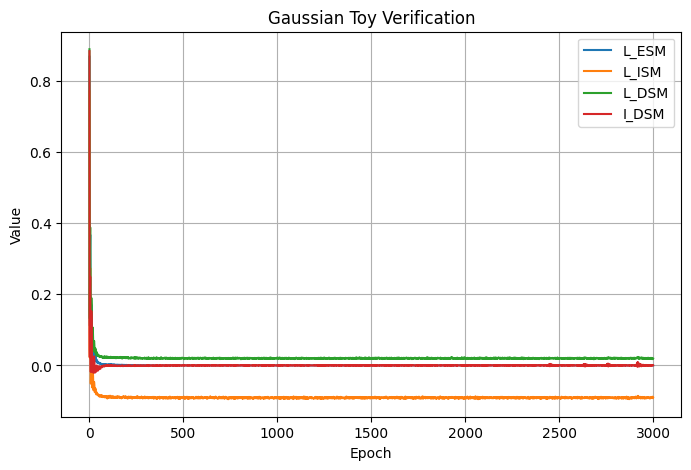

In [6]:
# ============================================================
# Plot losses
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(L_ESM_history, label='L_ESM')
plt.plot(L_ISM_history, label='L_ISM')
plt.plot(L_DSM_history, label='L_DSM')
plt.plot(I_DSM_history, label='I_DSM')

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Gaussian Toy Verification")
plt.legend()
plt.grid(True)

plt.show()

# Lagevin Sampling

In [7]:
# ============================================================
# Stable Langevin Sampling
# ============================================================

model.eval()

steps = 3000
step_size = 1e-4

#x_sample = torch.randn(5000, 1) * 2 + 10
x_sample = torch.randn(5000, 1) * np.sqrt(var + sigma**2) + mu

with torch.no_grad():
    for _ in range(steps):
        score = model(x_sample)
        noise = torch.randn_like(x_sample)

        x_sample = (
            x_sample
            + step_size * score
            + torch.sqrt(torch.tensor(2 * step_size)) * noise
        )

samples = x_sample.cpu().numpy().flatten()

print("Generated mean:", samples.mean())
print("Generated std:", samples.std())

Generated mean: 10.052252
Generated std: 3.245588


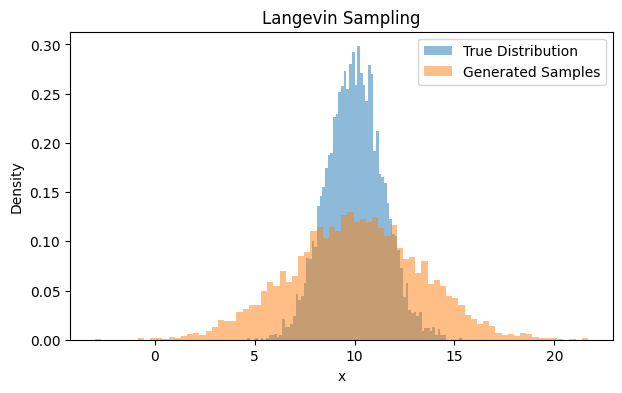

In [8]:
# ============================================================
# Plot generated samples
# ============================================================

true_samples = np.random.normal(
    mu,
    np.sqrt(var),
    5000
)

plt.figure(figsize=(7,4))

plt.hist(
    true_samples,
    bins=80,
    density=True,
    alpha=0.5,
    label='True Distribution'
)

plt.hist(
    samples,
    bins=80,
    density=True,
    alpha=0.5,
    label='Generated Samples'
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Langevin Sampling")
plt.legend()

plt.show()

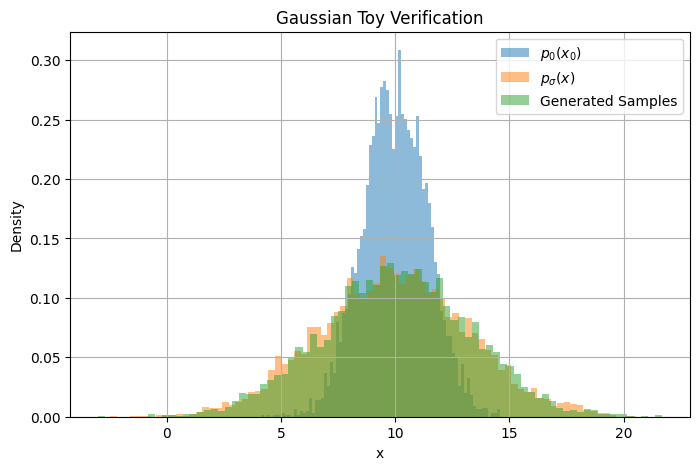

In [9]:
# ============================================================
# True distributions
# ============================================================

N_plot = 5000

# original distribution p0(x0)
x0_true = np.random.normal(
    mu,
    np.sqrt(var),
    N_plot
)

# noisy marginal distribution p_sigma(x)
x_true = np.random.normal(
    mu,
    np.sqrt(var + sigma**2),
    N_plot
)

# generated samples from Langevin
generated = samples

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    x0_true,
    bins=80,
    density=True,
    alpha=0.5,
    label=r'$p_0(x_0)$'
)

plt.hist(
    x_true,
    bins=80,
    density=True,
    alpha=0.5,
    label=r'$p_\sigma(x)$'
)

plt.hist(
    generated,
    bins=80,
    density=True,
    alpha=0.5,
    label='Generated Samples'
)

plt.xlabel("x")
plt.ylabel("Density")

plt.title("Gaussian Toy Verification")

plt.legend()
plt.grid(True)

plt.show()

In [13]:
# denoise generated samples back to x0 estimate
generated_tensor = torch.tensor(generated, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    score_generated = model(generated_tensor)
    x0_hat = generated_tensor + (sigma**2) * score_generated

#x0_hat = x0_hat.numpy().flatten()

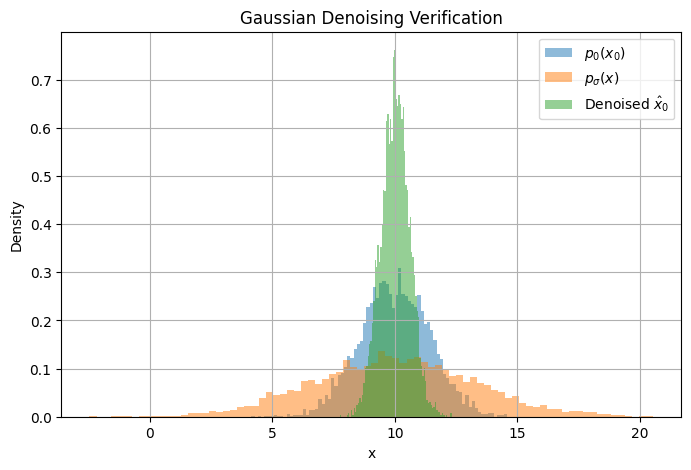

In [14]:
plt.figure(figsize=(8,5))

plt.hist(x0_true, bins=80, density=True, alpha=0.5, label=r'$p_0(x_0)$')
plt.hist(x_true, bins=80, density=True, alpha=0.5, label=r'$p_\sigma(x)$')
#plt.hist(generated, bins=80, density=True, alpha=0.5, label='Generated from $p_\sigma$')
plt.hist(x0_hat, bins=80, density=True, alpha=0.5, label=r'Denoised $\hat{x}_0$')

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Gaussian Denoising Verification")
plt.legend()
plt.grid(True)
plt.show()